In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci (1).csv


  DATASET LOADED SUCCESSFULLY

Shape     : 920 rows x 17 columns

Columns   : ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target']

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4

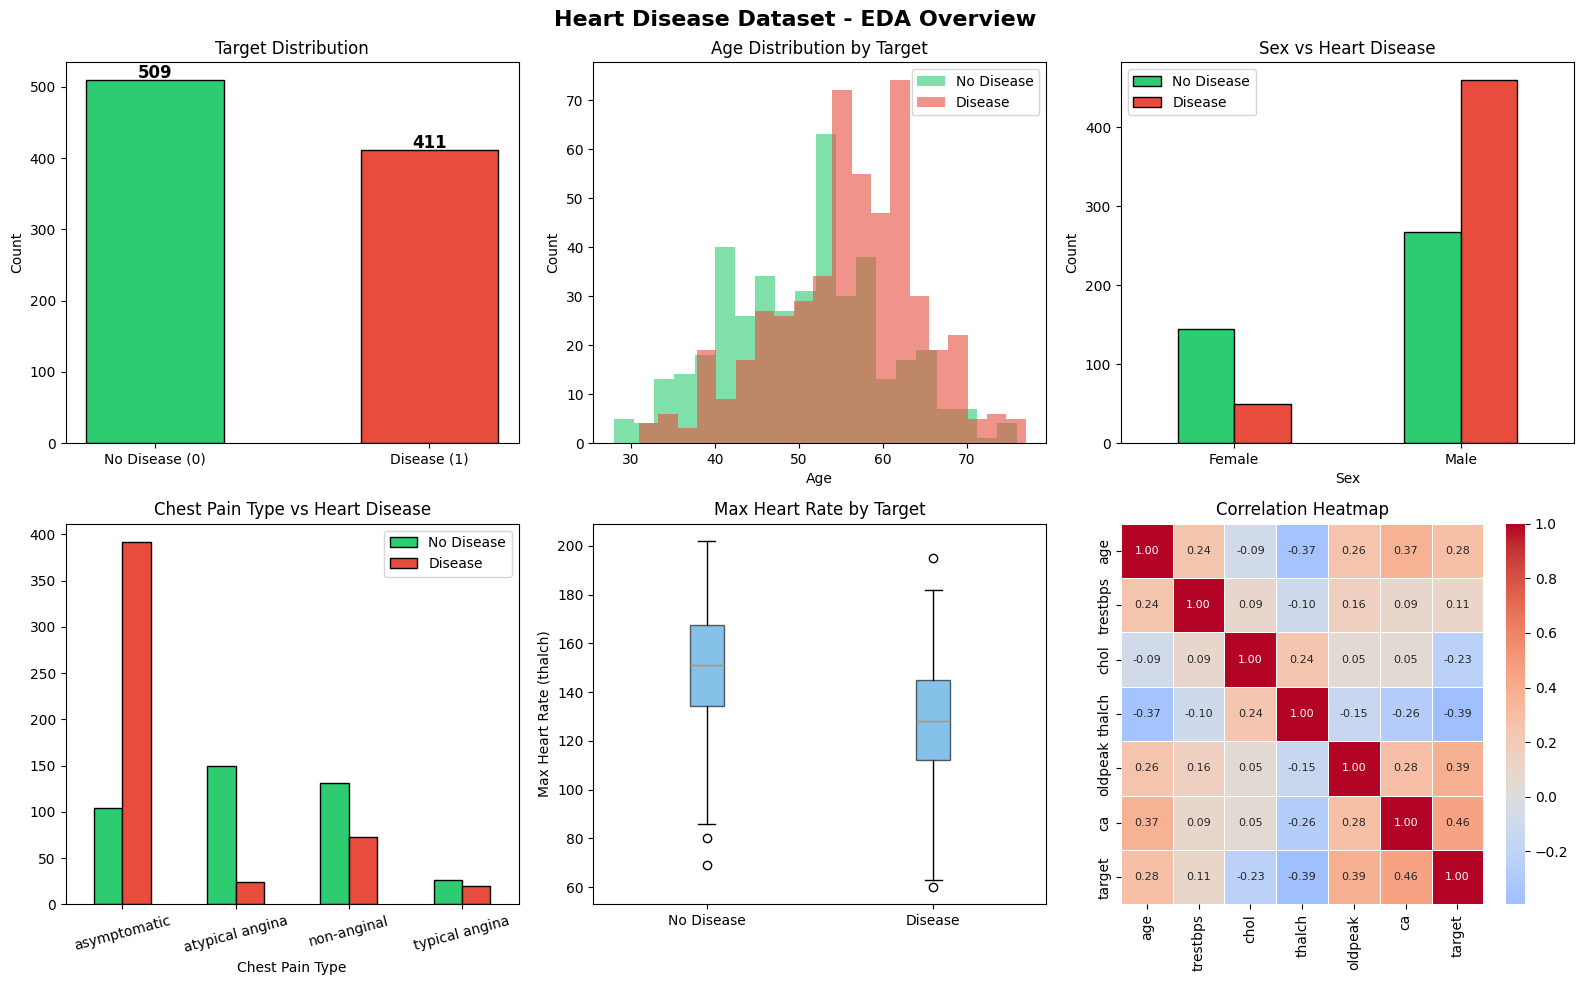

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load Dataset ──────────────────────────────────────────────────────────
# Upload your CSV in Colab first, then run this
df = pd.read_csv('heart_disease_uci (1).csv')

# Binarize target: 0 = no disease, 1 = disease
df['target'] = (df['num'] > 0).astype(int)

print("=" * 55)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 55)

# ── 2. Basic Info ────────────────────────────────────────────────────────────
print(f"\nShape     : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns   : {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)

# ── 3. Missing Values ────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing cells : {df.isnull().sum().sum()}")

# ── 4. Basic Statistics ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  BASIC STATISTICS")
print("=" * 55)
print(df.describe())

# ── 5. Target Distribution ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TARGET DISTRIBUTION")
print("=" * 55)
counts = df['target'].value_counts()
print(f"No Heart Disease (0) : {counts[0]} patients ({counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease    (1) : {counts[1]} patients ({counts[1]/len(df)*100:.1f}%)")

# ── 6. Unique values for categorical columns ─────────────────────────────────
print("\n" + "=" * 55)
print("  CATEGORICAL COLUMN UNIQUE VALUES")
print("=" * 55)
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']
for col in cat_cols:
    print(f"{col:10s}: {df[col].unique()}")

# ── 7. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Heart Disease Dataset - EDA Overview', fontsize=16, fontweight='bold')
colors = ['#2ecc71', '#e74c3c']

# Plot 1: Target Distribution
axes[0, 0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
               color=colors, edgecolor='black', width=0.5)
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)

# Plot 2: Age Distribution by Target
axes[0, 1].hist(df[df['target'] == 0]['age'], bins=20, alpha=0.6,
                color='#2ecc71', label='No Disease')
axes[0, 1].hist(df[df['target'] == 1]['age'], bins=20, alpha=0.6,
                color='#e74c3c', label='Disease')
axes[0, 1].set_title('Age Distribution by Target')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# Plot 3: Sex vs Heart Disease
sex_disease = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_disease.plot(kind='bar', ax=axes[0, 2], color=colors, edgecolor='black', rot=0)
axes[0, 2].set_title('Sex vs Heart Disease')
axes[0, 2].set_xlabel('Sex')
axes[0, 2].legend(['No Disease', 'Disease'])
axes[0, 2].set_ylabel('Count')

# Plot 4: Chest Pain Type vs Target
cp_disease = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_disease.plot(kind='bar', ax=axes[1, 0], color=colors, edgecolor='black', rot=15)
axes[1, 0].set_title('Chest Pain Type vs Heart Disease')
axes[1, 0].set_xlabel('Chest Pain Type')
axes[1, 0].legend(['No Disease', 'Disease'])

# Plot 5: Max Heart Rate by Target
axes[1, 1].boxplot(
    [df[df['target'] == 0]['thalch'].dropna(),
     df[df['target'] == 1]['thalch'].dropna()],
    labels=['No Disease', 'Disease'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6)
)
axes[1, 1].set_title('Max Heart Rate by Target')
axes[1, 1].set_ylabel('Max Heart Rate (thalch)')

# Plot 6: Correlation Heatmap (numerical only)
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1, 2], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

Preprocessing

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('heart_disease_uci (1).csv')
df['target'] = (df['num'] > 0).astype(int)

print("Original shape:", df.shape)

# ── 2. Drop unnecessary columns ──────────────────────────────────────────────
# 'id'      - just a row number, no predictive value
# 'num'     - original target (we already made 'target' from it)
# 'dataset' - hospital source, not a medical feature
# 'ca'      - 66% missing, too much to impute reliably
# 'thal'    - 52% missing, too much to impute reliably
# 'slope'   - 33% missing, too much to impute reliably

df.drop(columns=['id', 'num', 'dataset', 'ca', 'thal', 'slope'], inplace=True)
print("After dropping columns:", df.shape)
print("Remaining columns:", list(df.columns))

# ── 3. Handle Missing Values ─────────────────────────────────────────────────
print("\n--- Missing values BEFORE imputation ---")
print(df.isnull().sum())

# Numerical columns → fill with MEDIAN (robust to outliers)
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled '{col}' missing values with median: {median_val}")

# Categorical columns → fill with MODE (most frequent value)
cat_cols = ['fbs', 'restecg', 'exang']
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"Filled '{col}' missing values with mode: {mode_val}")

print("\n--- Missing values AFTER imputation ---")
print(df.isnull().sum())

# ── 4. Encode Categorical Features ───────────────────────────────────────────
# Convert text categories to numbers so the model can understand them

# Binary columns (only 2 values) → map directly to 0/1
df['sex']  = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs']  = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})

# Multi-category columns → One Hot Encoding
# Creates separate 0/1 column for each category
# drop_first=True avoids the "dummy variable trap"
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)

print("\n--- After Encoding ---")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head())

# ── 5. Split Features and Target ─────────────────────────────────────────────
X = df.drop(columns=['target'])
y = df['target']

print("\n--- Features (X) shape:", X.shape)
print("--- Target  (y) shape:", y.shape)
print("\nFeature columns:", list(X.columns))

# ── 6. Scale Numerical Features ──────────────────────────────────────────────
# Logistic Regression is sensitive to scale
# StandardScaler → transforms each feature to mean=0, std=1

scaler = StandardScaler()
num_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
X[num_features] = scaler.fit_transform(X[num_features])

print("\n--- After Scaling (first 5 rows) ---")
print(X.head())

print("\n✅ Preprocessing Complete!")
print(f"Final dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Original shape: (920, 17)
After dropping columns: (920, 11)
Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'target']

--- Missing values BEFORE imputation ---
age          0
sex          0
cp           0
trestbps    59
chol        30
fbs         90
restecg      2
thalch      55
exang       55
oldpeak     62
target       0
dtype: int64
Filled 'trestbps' missing values with median: 130.0
Filled 'chol' missing values with median: 223.0
Filled 'thalch' missing values with median: 140.0
Filled 'oldpeak' missing values with median: 0.5
Filled 'fbs' missing values with mode: False
Filled 'restecg' missing values with mode: normal
Filled 'exang' missing values with mode: False

--- Missing values AFTER imputation ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
target      0
dtype: int64

--- After Encoding ---
Shape: (920, 14)
Columns: ['a

Train/Test Split + Training the Model

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ── 1. Reproduce Preprocessing from Step 2 ───────────────────────────────────
df = pd.read_csv('/content/heart_disease_uci (1).csv')
df['target'] = (df['num'] > 0).astype(int)
df.drop(columns=['id', 'num', 'dataset', 'ca', 'thal', 'slope'], inplace=True)

# Fill missing values
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = ['fbs', 'restecg', 'exang']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode
df['sex']   = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs']   = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)

# Fix True/False → 1/0 for OHE columns
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Split X and y
X = df.drop(columns=['target'])
y = df['target']

# Scale
scaler = StandardScaler()
num_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
X[num_features] = scaler.fit_transform(X[num_features])

# ── 2. Train/Test Split ───────────────────────────────────────────────────────
# 80% for training, 20% for testing
# stratify=y → ensures both splits have same 45/55 class ratio
# random_state=42 → makes results reproducible every time you run

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 55)
print("  TRAIN / TEST SPLIT")
print("=" * 55)
print(f"Total samples   : {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")

print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTesting target distribution:")
print(y_test.value_counts())

# ── 3. Train Logistic Regression ─────────────────────────────────────────────
# max_iter=1000 → give the model enough iterations to converge
# random_state=42 → reproducibility

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("\n" + "=" * 55)
print("  MODEL TRAINED SUCCESSFULLY")
print("=" * 55)
print(f"Number of features used : {X_train.shape[1]}")
print(f"Feature names           : {list(X.columns)}")

# ── 4. Peek at what the model learned ────────────────────────────────────────
coefficients = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\n" + "=" * 55)
print("  MODEL COEFFICIENTS (what the model learned)")
print("=" * 55)
print(coefficients.to_string(index=False))
print("\n✅ Model Training Complete! Ready for evaluation in Step 4.")

  TRAIN / TEST SPLIT
Total samples   : 920
Training samples: 736 (80%)
Testing samples : 184  (20%)

Training target distribution:
target
1    407
0    329
Name: count, dtype: int64

Testing target distribution:
target
1    102
0     82
Name: count, dtype: int64

  MODEL TRAINED SUCCESSFULLY
Number of features used : 13
Feature names           : ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']

  MODEL COEFFICIENTS (what the model learned)
                 Feature  Coefficient
                     sex     1.165671
                   exang     1.012720
                 oldpeak     0.517077
                     fbs     0.400249
                     age     0.327915
                trestbps     0.069133
restecg_st-t abnormality    -0.054686
          restecg_normal    -0.275744
                  thalch    -0.335978
                    chol    -0.370085
       c

Evaluation

  EVALUATION METRICS
Accuracy  : 0.8315  (83.15%)
Precision : 0.8198
Recall    : 0.8922
F1 Score  : 0.8545
ROC-AUC   : 0.9041

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.85      0.76      0.80        82
     Disease       0.82      0.89      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.83       184
weighted avg       0.83      0.83      0.83       184

  CONFUSION MATRIX BREAKDOWN
True Negatives  (TN) : 62  → Correctly predicted NO disease
True Positives  (TP) : 91  → Correctly predicted HAS disease
False Positives (FP) : 20  → Predicted disease, actually healthy  ⚠️
False Negatives (FN) : 11  → Missed disease, predicted healthy    ❌


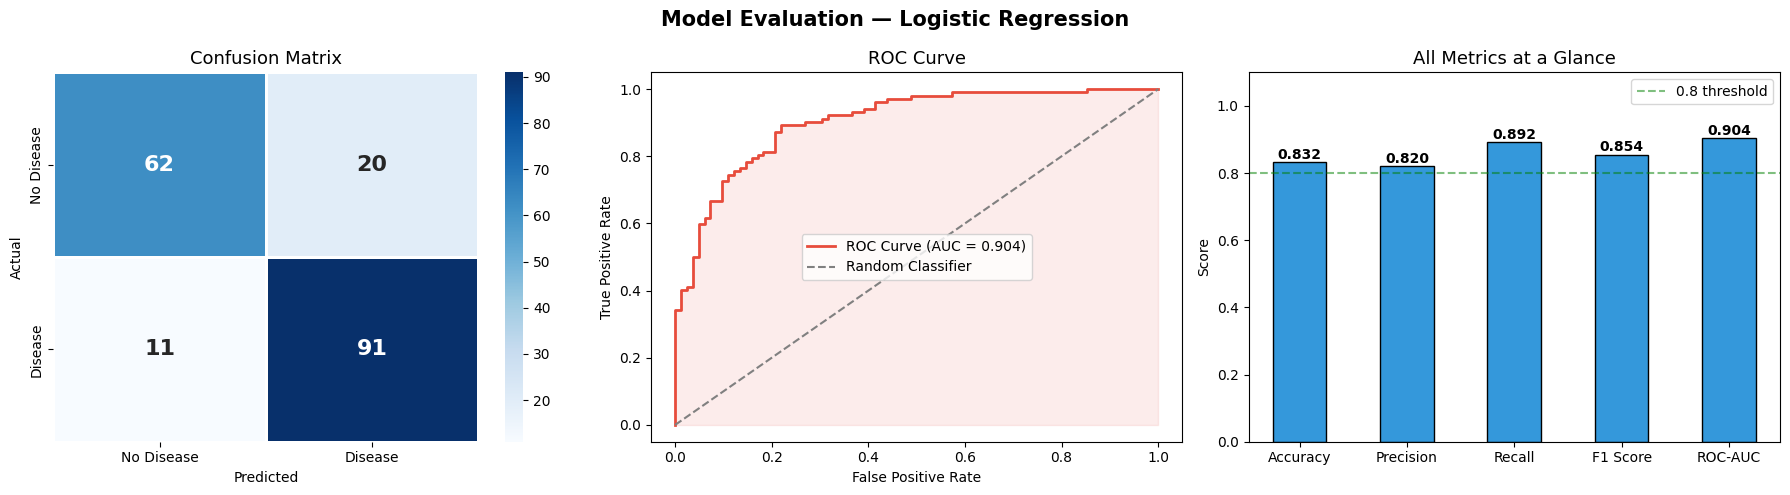


✅ Evaluation Complete!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# ── 1. Reproduce Steps 1-3 ───────────────────────────────────────────────────
df = pd.read_csv('/content/heart_disease_uci (1).csv')
df['target'] = (df['num'] > 0).astype(int)
df.drop(columns=['id', 'num', 'dataset', 'ca', 'thal', 'slope'], inplace=True)

for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col].fillna(df[col].median(), inplace=True)
for col in ['fbs', 'restecg', 'exang']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['sex']   = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs']   = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']] = scaler.fit_transform(
    X[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ── 2. Make Predictions ───────────────────────────────────────────────────────
y_pred       = model.predict(X_test)           # class prediction  → 0 or 1
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of disease → 0.0 to 1.0

# ── 3. Core Metrics ───────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("=" * 55)
print("  EVALUATION METRICS")
print("=" * 55)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n" + "=" * 55)
print("  CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# ── 4. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("=" * 55)
print("  CONFUSION MATRIX BREAKDOWN")
print("=" * 55)
print(f"True Negatives  (TN) : {TN}  → Correctly predicted NO disease")
print(f"True Positives  (TP) : {TP}  → Correctly predicted HAS disease")
print(f"False Positives (FP) : {FP}  → Predicted disease, actually healthy  ⚠️")
print(f"False Negatives (FN) : {FN}  → Missed disease, predicted healthy    ❌")

# ── 5. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — Logistic Regression', fontsize=15, fontweight='bold')

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5,
             linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Plot 3: Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
values  = [accuracy, precision, recall, f1, roc_auc]
bar_colors = ['#3498db' if v >= 0.8 else '#e67e22' for v in values]
bars = axes[2].bar(metrics, values, color=bar_colors, edgecolor='black', width=0.5)
axes[2].set_ylim(0, 1.1)
axes[2].set_title('All Metrics at a Glance', fontsize=13)
axes[2].set_ylabel('Score')
axes[2].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='0.8 threshold')
axes[2].legend()
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n✅ Evaluation Complete!")

 Feature Importance & Interpretation

  FEATURE IMPORTANCE (by coefficient)
                 Feature  Coefficient
      cp_atypical angina    -1.852341
          cp_non-anginal    -1.099524
       cp_typical angina    -0.910065
                    chol    -0.370085
                  thalch    -0.335978
          restecg_normal    -0.275744
restecg_st-t abnormality    -0.054686
                trestbps     0.069133
                     age     0.327915
                     fbs     0.400249
                 oldpeak     0.517077
                   exang     1.012720
                     sex     1.165671

  ODDS RATIOS
                 Feature  Coefficient  Odds_Ratio
                     sex     1.165671    3.208075
                   exang     1.012720    2.753078
                 oldpeak     0.517077    1.677119
                     fbs     0.400249    1.492196
                     age     0.327915    1.388071
                trestbps     0.069133    1.071578
restecg_st-t abnormality    -0.054686    0.946782
          reste

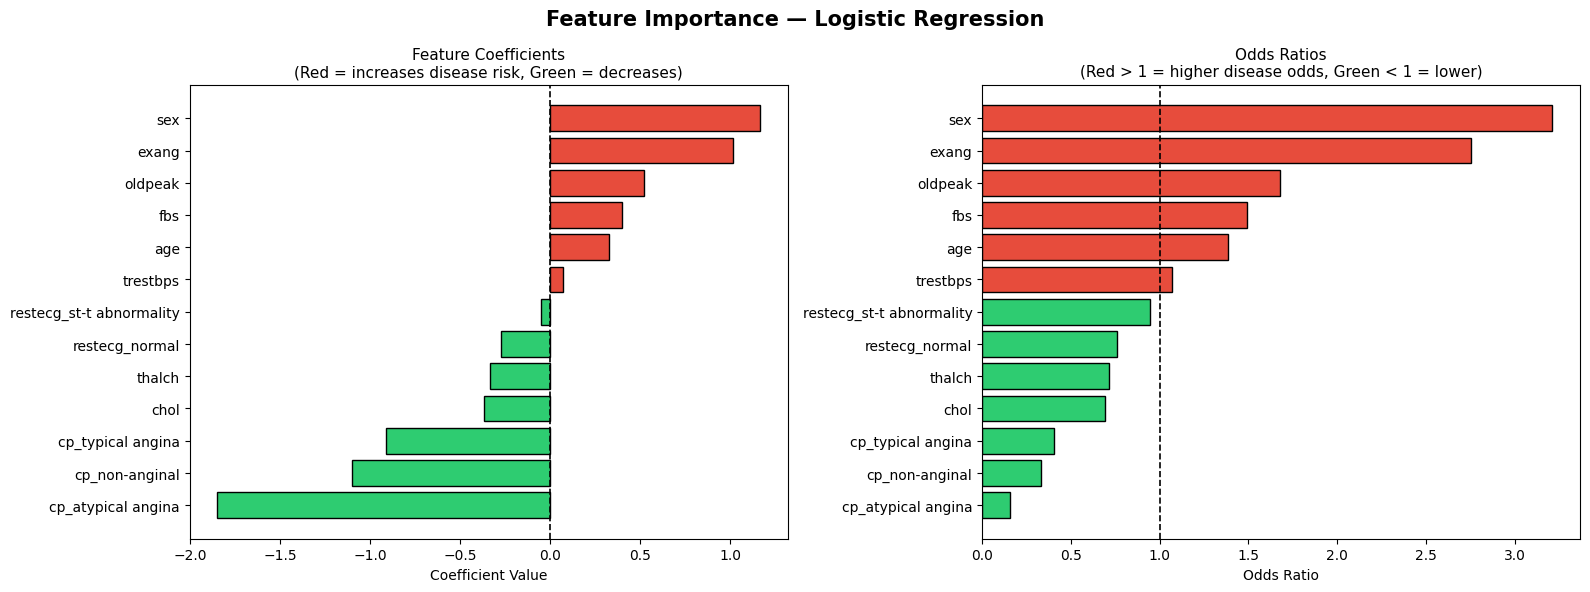


✅ All 5 Steps Complete! Your Heart Disease Prediction Model is ready.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ── 1. Reproduce Steps 1-3 ───────────────────────────────────────────────────
df = pd.read_csv('/content/heart_disease_uci (1).csv')
df['target'] = (df['num'] > 0).astype(int)
df.drop(columns=['id', 'num', 'dataset', 'ca', 'thal', 'slope'], inplace=True)

for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col].fillna(df[col].median(), inplace=True)
for col in ['fbs', 'restecg', 'exang']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['sex']   = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs']   = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']] = scaler.fit_transform(
    X[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ── 2. Feature Importance via Coefficients ───────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coef'   : np.abs(model.coef_[0])
}).sort_values('Coefficient', ascending=True)

print("=" * 60)
print("  FEATURE IMPORTANCE (by coefficient)")
print("=" * 60)
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

# ── 3. Odds Ratio ────────────────────────────────────────────────────────────
# Odds Ratio = e^coefficient
# Tells us HOW MUCH more likely disease is per unit change in feature

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print("\n" + "=" * 60)
print("  ODDS RATIOS")
print("=" * 60)
print(coef_df[['Feature', 'Coefficient', 'Odds_Ratio']].sort_values(
    'Odds_Ratio', ascending=False).to_string(index=False))

# ── 4. Predict on a New Patient ──────────────────────────────────────────────
# Let's simulate 2 patients and see what the model predicts

print("\n" + "=" * 60)
print("  PREDICTING ON NEW PATIENTS")
print("=" * 60)

# Patient A — high risk profile
# Patient B — low risk profile
new_patients_raw = pd.DataFrame({
    'age'                     : [62,  35],
    'sex'                     : [1,   0],    # 1=Male, 0=Female
    'trestbps'                : [150, 120],
    'chol'                    : [280, 180],
    'fbs'                     : [1,   0],
    'thalch'                  : [110, 175],
    'exang'                   : [1,   0],
    'oldpeak'                 : [2.5, 0.2],
    'cp_atypical angina'      : [0,   1],
    'cp_non-anginal'          : [0,   0],
    'cp_typical angina'       : [0,   0],
    'restecg_normal'          : [0,   1],
    'restecg_st-t abnormality': [0,   0],
})

# Scale numerical features using the SAME scaler from training
new_patients = new_patients_raw.copy()
new_patients[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']] = scaler.transform(
    new_patients[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']]
)

predictions  = model.predict(new_patients)
probabilities = model.predict_proba(new_patients)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    label = "❌ DISEASE PREDICTED" if pred == 1 else "✅ NO DISEASE PREDICTED"
    print(f"\nPatient {'A' if i == 0 else 'B'} ({'High Risk Profile' if i==0 else 'Low Risk Profile'})")
    print(f"  Probability of No Disease : {prob[0]*100:.1f}%")
    print(f"  Probability of Disease    : {prob[1]*100:.1f}%")
    print(f"  Prediction                : {label}")

# ── 5. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Logistic Regression', fontsize=15, fontweight='bold')

# Plot 1: Coefficient plot
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_title('Feature Coefficients\n(Red = increases disease risk, Green = decreases)', fontsize=11)
axes[0].set_xlabel('Coefficient Value')

# Plot 2: Odds Ratio plot
coef_sorted = coef_df.sort_values('Odds_Ratio', ascending=True)
or_colors = ['#e74c3c' if o > 1 else '#2ecc71' for o in coef_sorted['Odds_Ratio']]
axes[1].barh(coef_sorted['Feature'], coef_sorted['Odds_Ratio'],
             color=or_colors, edgecolor='black')
axes[1].axvline(x=1, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Odds Ratios\n(Red > 1 = higher disease odds, Green < 1 = lower)', fontsize=11)
axes[1].set_xlabel('Odds Ratio')

plt.tight_layout()
plt.show()
print("\n✅ All 5 Steps Complete! Your Heart Disease Prediction Model is ready.")